<a href="https://colab.research.google.com/github/lalunru/Malicious-URL-Classification/blob/main/(%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5)_%EC%95%85%EC%84%B1_URL_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 라이브러리 불러 오기

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Dropout, Flatten

## 2. 데이터 업로드 (라벨링 된 URL)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/malicious_phish.csv'
df = pd.read_csv(file_path)

## 3. 데이터 확인과 전처리

In [ ]:
import tensorflow as tf
import keras
import sklearn

In [ ]:
import math
import re
from urllib.parse import urlparse, parse_qs

class URLFeatureAnalyzer:
    def __init__(self, url):
        self.url = url.strip()
        self.parsed = urlparse(self.url)
        self.domain = self.parsed.hostname or ''

    def _calculate_entropy(self):
        freq = {char: self.url.count(char) / len(self.url) for char in set(self.url)}
        return -sum(p * math.log2(p) for p in freq.values())

    def _is_ip_address(self):
        match = re.match(r'^\d{1,3}(\.\d{1,3}){3}$', self.domain)
        if not match:
            return False
        return all(0 <= int(part) <= 255 for part in self.domain.split('.'))

    def extract_features(self):
        features = {
            "url": self.url,
            "entropy": self._calculate_entropy(),
            "url_length": len(self.url),
            "num_digits": sum(char.isdigit() for char in self.url),
            "num_parameters": len(parse_qs(self.parsed.query)),
            "num_fragments": 1 if self.parsed.fragment else 0,
            "num_subdomains": len(self.domain.split('.')) - 2 if self.domain.count('.') >= 2 else 0,
            "domain_extension": self.domain.split('.')[-1] if '.' in self.domain else '',
            "contains_http": 'http' in self.url,
            "contains_https": 'https' in self.url,
            "is_ip": self._is_ip_address(),
            "count_%20": self.url.count('%20'),
            "count_@": self.url.count('@'),
        }
        return features

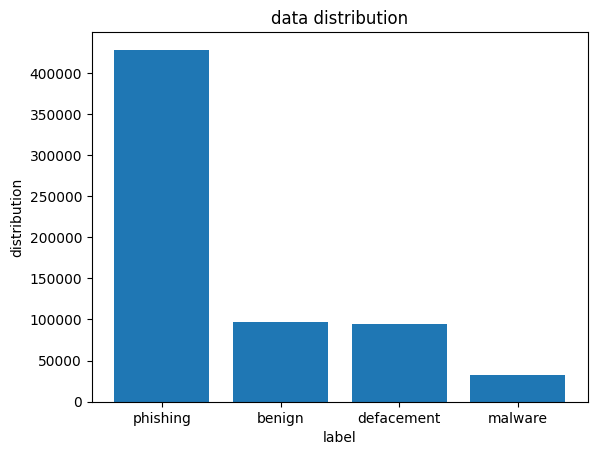

In [ ]:
counts = df["type"].value_counts()
plt.bar(df["type"].unique(),counts)
plt.title('data distribution')
plt.xlabel('label')
plt.ylabel('distribution')
plt.show()

## 4. 데이터 균형 조정

type
phishing      30000
benign        30000
defacement    30000
malware       23645
Name: count, dtype: int64


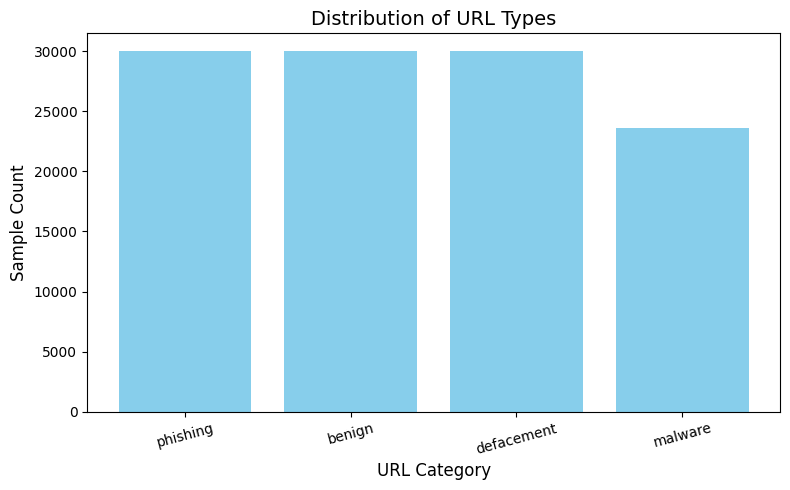

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 정리: 결측치 및 중복 제거
cleaned_urls = df.dropna().drop_duplicates()

# 2. 라벨별 데이터 분리
label_groups = {
    'benign': cleaned_urls[cleaned_urls['type'] == 'benign'],
    'malicious': cleaned_urls[cleaned_urls['type'] == 'malware'],
    'deface': cleaned_urls[cleaned_urls['type'] == 'defacement'],
    'phish': cleaned_urls[cleaned_urls['type'] == 'phishing']
}

# 3. 데이터 균형 맞추기 (샘플링 수 지정)
sample_size = 30000
balanced_subsets = [
    label_groups['benign'].sample(n=sample_size, random_state=101),
    label_groups['deface'].sample(n=sample_size, random_state=101),
    label_groups['phish'].sample(n=sample_size, random_state=101),
    label_groups['malicious']  # 이 클래스는 샘플링 안 함
]

# 4. 균형 잡힌 데이터셋 생성 및 섞기
balanced_df = pd.concat(balanced_subsets, ignore_index=True)
shuffled_data = balanced_df.sample(frac=1.0, random_state=202).reset_index(drop=True)

# 5. 라벨 분포 출력 및 시각화
label_counts = shuffled_data['type'].value_counts()
print(label_counts)

# 6. 분포 그래프 출력
plt.figure(figsize=(8,5))
plt.bar(label_counts.index, label_counts.values, color='skyblue')
plt.title('Distribution of URL Types', fontsize=14)
plt.xlabel('URL Category', fontsize=12)
plt.ylabel('Sample Count', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 5. URL 특성 추출 및 학습 데이터 구성

In [ ]:
from tqdm import tqdm

# 특징 추출 결과 저장용 리스트
url_feature_list = []

# tqdm으로 진행 표시하면서 반복
for raw_url in tqdm(shuffled_data['url'], desc="Extracting features"):
    extractor = URLFeatureAnalyzer(raw_url)
    extracted = extractor.extract_features()
    url_feature_list.append(extracted)

# 총 추출된 항목 수 확인
print(f"Total extracted feature sets: {len(url_feature_list)}")

# 리스트 → DataFrame 변환
feature_df = pd.DataFrame(url_feature_list)

Extracting features: 100%|██████████| 113645/113645 [00:04<00:00, 28104.40it/s]


Total extracted feature sets: 113645


In [ ]:
feature_df["type"] = shuffled_data["type"] # URL에 해당하는 type 라벨 추가
feature_df.head()

,url,entropy,url_length,num_digits,num_parameters,num_fragments,num_subdomains,domain_extension,contains_http,contains_https,is_ip,count_%20,count_@,type
0,courses.cs.vt.edu/~cs3604/lib/Netiquette/Rinaldi/,4.278303,49,4,0,0,0,,False,False,False,0,0,phishing
1,http://classic.theinflammatorytruth.com/4810fc...,4.809267,69,9,0,0,1,com,True,False,False,0,0,malware
2,thehouseofcards.com/cribbage.html,4.043802,33,0,0,0,0,,False,False,False,0,0,phishing
3,youtube.com/watch?v=s4hFPWY9GqU,4.631616,31,2,1,0,0,,False,False,False,0,0,benign
4,http://appelboerderij.nl/kampeerboerderij-/1-k...,4.284902,105,7,1,0,0,nl,True,False,False,0,0,defacement


In [ ]:
feature_df = feature_df.dropna(subset=['type']) # 라벨이 없는 데이터 제거
feature_df["type"].value_counts() # 학습 전 클래스 비율 검토

,count
type,
phishing,30000
benign,30000
defacement,30000
malware,23645


## 6. 텍스트 시퀀스화

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# 텍스트 전처리: 토큰화 + 시퀀스 인코딩
vocab_limit = 10000
sequence_length = 100

text_encoder = Tokenizer(num_words=vocab_limit, oov_token="<UNK>")
text_encoder.fit_on_texts(feature_df['url'])

tokenized_urls = text_encoder.texts_to_sequences(feature_df['url'])
padded_urls = pad_sequences(tokenized_urls, maxlen=sequence_length, padding='post', truncating='post')

In [ ]:
class_encoder = LabelEncoder()
feature_df['category_id'] = class_encoder.fit_transform(feature_df['type'])
target_matrix = to_categorical(feature_df['category_id'], num_classes=4)

In [ ]:
feature_df.head()

,url,entropy,url_length,num_digits,num_parameters,num_fragments,num_subdomains,domain_extension,contains_http,contains_https,is_ip,count_%20,count_@,type,category_id
0,courses.cs.vt.edu/~cs3604/lib/Netiquette/Rinaldi/,4.278303,49,4,0,0,0,,False,False,False,0,0,phishing,3
1,http://classic.theinflammatorytruth.com/4810fc...,4.809267,69,9,0,0,1,com,True,False,False,0,0,malware,2
2,thehouseofcards.com/cribbage.html,4.043802,33,0,0,0,0,,False,False,False,0,0,phishing,3
3,youtube.com/watch?v=s4hFPWY9GqU,4.631616,31,2,1,0,0,,False,False,False,0,0,benign,0
4,http://appelboerderij.nl/kampeerboerderij-/1-k...,4.284902,105,7,1,0,0,nl,True,False,False,0,0,defacement,1


In [ ]:
numeric_columns = [
    'entropy', 'num_digits', 'url_length', 'num_parameters',
    'contains_http', 'contains_https', 'is_ip',
    'count_%20', 'count_@'
]
extra_inputs = feature_df[numeric_columns].astype(np.int32).values

## 7. 혼합 신경망 모델 구성

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate

# URL 시퀀스 입력
url_input = Input(shape=(sequence_length,), name="url_input")  # e.g. 100
embedding_layer = Embedding(input_dim=vocab_limit, output_dim=64)(url_input)
lstm_output = LSTM(64)(embedding_layer)  # return_sequences=False by default

# 추가 수치형 입력 (추가 피처 9개)
extra_input = Input(shape=(extra_inputs.shape[1],), name="extra_features")
dense_extra = Dense(32, activation="relu")(extra_input)

# 두 입력을 결합
combined = Concatenate()([lstm_output, dense_extra])
hidden = Dense(64, activation="relu")(combined)
dropout_layer = Dropout(0.5)(hidden)

# 최종 출력층: 클래스 4개 (softmax)
output_layer = Dense(4, activation="softmax", name="output")(dropout_layer)

# 모델 정의
model = Model(inputs=[url_input, extra_input], outputs=output_layer)

# 모델 컴파일
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# 모델 구조 출력
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ url_input           │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │    640,000 │ url_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extra_features      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        320 │ extra_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │        260 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 679,812 (2.59 MB)

 Trainable params: 679,812 (2.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X_train_seq, X_test_seq, X_train_extra, X_test_extra, y_train, y_test = train_test_split(
    padded_urls, extra_inputs, target_matrix,
    test_size=0.2,
    random_state=123
)

In [ ]:
history = model.fit(
    [X_train_seq, X_train_extra], y_train,
    epochs=20,
    batch_size=32,
    validation_data=([X_test_seq, X_test_extra], y_test),
    verbose=1
)

Epoch 1/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 214s 74ms/step - accuracy: 0.5565 - loss: 1.2942 - val_accuracy: 0.7060 - val_loss: 0.6552
Epoch 2/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 248s 69ms/step - accuracy: 0.6888 - loss: 0.7207 - val_accuracy: 0.6982 - val_loss: 0.6733
Epoch 3/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 202s 71ms/step - accuracy: 0.6919 - loss: 0.6972 - val_accuracy: 0.7267 - val_loss: 0.6317
Epoch 4/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 206s 72ms/step - accuracy: 0.6968 - loss: 0.6847 - val_accuracy: 0.7140 - val_loss: 0.6233
Epoch 5/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 205s 72ms/step - accuracy: 0.7002 - loss: 0.6689 - val_accuracy: 0.7272 - val_loss: 0.6088
Epoch 6/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 203s 71ms/step - accuracy: 0.7070 - loss: 0.6538 - val_accuracy: 0.7258 - val_loss: 0.6006
Epoch 7/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 267s 73ms/step - accuracy: 0.7094 - loss: 0.6468 - val_accuracy: 0.7379 - val_loss: 0.6049
Epoch 8/20
2842/2842 ━━━━━━━━━━━━━━━━━━━━ 197s 69ms/step - accuracy: 

In [ ]:
loss, accuracy = model.evaluate([X_test_seq,X_test_extra], y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

711/711 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9196 - loss: 0.2322
Test Loss: 0.2280900776386261
Test Accuracy: 0.9195741415023804


In [ ]:
y_pred = model.predict([X_test_seq,X_test_extra])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred_classes, target_names=class_encoder.classes_))

711/711 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
              precision    recall  f1-score   support

      benign       0.87      0.94      0.90      6018
  defacement       1.00      0.99      0.99      6055
     malware       0.97      0.87      0.92      4733
    phishing       0.86      0.87      0.86      5923

    accuracy                           0.92     22729
   macro avg       0.92      0.92      0.92     22729
weighted avg       0.92      0.92      0.92     22729



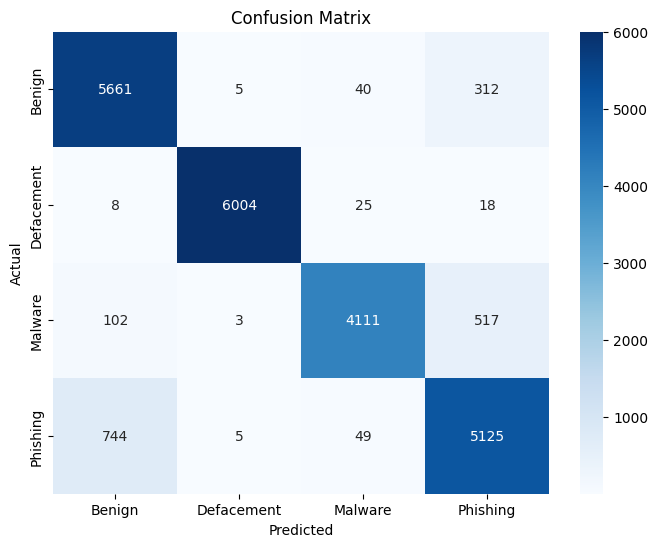

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign", "Defacement", "Malware", "Phishing"], yticklabels=["Benign", "Defacement", "Malware", "Phishing"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()